In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/CPROJECT/"

df = pd.read_csv(DATA_PATH + "master_clean_m1.csv")

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_date"] = df["order_purchase_timestamp"].dt.date

print("Data loaded ✅")


Mounted at /content/drive
Data loaded ✅


Build Daily Product Demand

In [4]:
daily_prod = (
    df.groupby(["product_id","order_date"])
      .size()
      .reset_index(name="qty")
)

daily_prod.head()

,product_id,order_date,qty
0,00066f42aeeb9f3007548bb9d3f33c38,2018-05-20,1
1,00088930e925c41fd95ebfe695fd2655,2017-12-12,1
2,0009406fd7479715e4bef61dd91f2462,2017-12-21,1
3,000b8f95fcb9e0096488278317764d19,2018-08-01,1
4,000b8f95fcb9e0096488278317764d19,2018-08-10,1


Product Summary Stats

In [5]:
prod_stats = daily_prod.groupby("product_id").agg(
    total_units=("qty","sum"),
    avg_daily=("qty","mean"),
    std_daily=("qty","std"),
    active_days=("qty","count")
).fillna(0)

prod_stats.head()

,total_units,avg_daily,std_daily,active_days
product_id,,,,
00066f42aeeb9f3007548bb9d3f33c38,1,1.0,0.0,1
00088930e925c41fd95ebfe695fd2655,1,1.0,0.0,1
0009406fd7479715e4bef61dd91f2462,1,1.0,0.0,1
000b8f95fcb9e0096488278317764d19,2,1.0,0.0,2
000d9be29b5207b54e86aa1b1ac54872,1,1.0,0.0,1


SELECT 20 PRODUCTS

Select Top 20 by Volume

In [6]:
top_products = prod_stats.sort_values(
    "total_units", ascending=False
).head(20).copy()

top_products.head()

,total_units,avg_daily,std_daily,active_days
product_id,,,,
aca2eb7d00ea1a7b8ebd4e68314663af,520,3.040936,2.322161,171
422879e10f46682990de24d770e7f83d,484,2.469388,2.716348,196
99a4788cb24856965c36a24e339b6058,477,1.813688,1.241568,263
389d119b48cf3043d311335e499d9c6b,390,2.063492,1.814888,189
368c6c730842d78016ad823897a372db,388,2.179775,2.183978,178


Add Price Info

In [7]:
price_map = df.groupby("product_id")["price"].mean()

top_products["unit_cost"] = top_products.index.map(price_map)

EOQ PARAMETERS

Define Constants

In [8]:
ORDER_COST = 100        # S
HOLD_RATE = 0.20        # 20%
LEAD_TIME = 7           # days
Z = 1.65                # 95% service level
DAYS_YEAR = 365

Annual Demand + Holding Cost

In [9]:
top_products["annual_demand"] = (
    top_products["total_units"] /
    top_products["active_days"] * DAYS_YEAR
)

top_products["holding_cost"] = (
    top_products["unit_cost"] * HOLD_RATE
)

EOQ CALCULATION

EOQ Formula

In [10]:
top_products["EOQ"] = np.sqrt(
    (2 * top_products["annual_demand"] * ORDER_COST) /
    top_products["holding_cost"]
)

top_products["EOQ"] = top_products["EOQ"].round()

Cost Components

In [11]:
top_products["orders_per_year"] = (
    top_products["annual_demand"] / top_products["EOQ"]
)

top_products["ordering_cost"] = (
    top_products["orders_per_year"] * ORDER_COST
)

top_products["holding_cost_total"] = (
    (top_products["EOQ"]/2) * top_products["holding_cost"]
)

top_products["total_inventory_cost"] = (
    top_products["ordering_cost"] +
    top_products["holding_cost_total"]
)

SAFETY STOCK + ROP

Safety Stock

In [12]:
top_products["safety_stock"] = (
    Z * top_products["std_daily"] * np.sqrt(LEAD_TIME)
).round()


Reorder Point

In [13]:
top_products["ROP"] = (
    top_products["avg_daily"] * LEAD_TIME +
    top_products["safety_stock"]
).round()

top_products["max_inventory"] = (
    top_products["ROP"] + top_products["EOQ"]
)

top_products["avg_inventory"] = (
    (top_products["EOQ"]/2) +
    top_products["safety_stock"]
)

CURRENT VS PROPOSED COST

Cost Comparison

In [14]:
CURRENT_Q = 200

top_products["current_cost"] = (
    (top_products["annual_demand"]/CURRENT_Q)*ORDER_COST +
    (CURRENT_Q/2)*top_products["holding_cost"]
)

top_products["proposed_cost"] = (
    (top_products["annual_demand"]/top_products["EOQ"])*ORDER_COST +
    top_products["avg_inventory"]*top_products["holding_cost"]
)

top_products["savings"] = (
    top_products["current_cost"] -
    top_products["proposed_cost"]
)

top_products["savings_pct"] = (
    top_products["savings"] /
    top_products["current_cost"] * 100
)

ABC ANALYSIS (ALL PRODUCTS)

Revenue by Product

In [15]:
prod_rev = df.groupby("product_id")["price"].sum()

abc = prod_rev.sort_values(ascending=False).reset_index()
abc.columns = ["product_id","revenue"]

abc["cum_rev_pct"] = (
    abc["revenue"].cumsum() /
    abc["revenue"].sum() * 100
)

ABC Classification

In [16]:
def abc_class(p):
    if p <= 80:
        return "A"
    elif p <= 95:
        return "B"
    else:
        return "C"

abc["ABC"] = abc["cum_rev_pct"].apply(abc_class)

abc.head()


,product_id,revenue,cum_rev_pct,ABC
0,bb50f2e236e5eea0100680137654686c,63560.00,0.480778,A
1,6cdd53843498f92890544667809f1595,53652.30,0.886612,A
2,d6160fb7873f184099d9bc95e30376af,45949.35,1.234180,A
3,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,1.579261,A
4,99a4788cb24856965c36a24e339b6058,42049.66,1.897331,A


REQUIRED CHARTS

ABC Pareto Chart

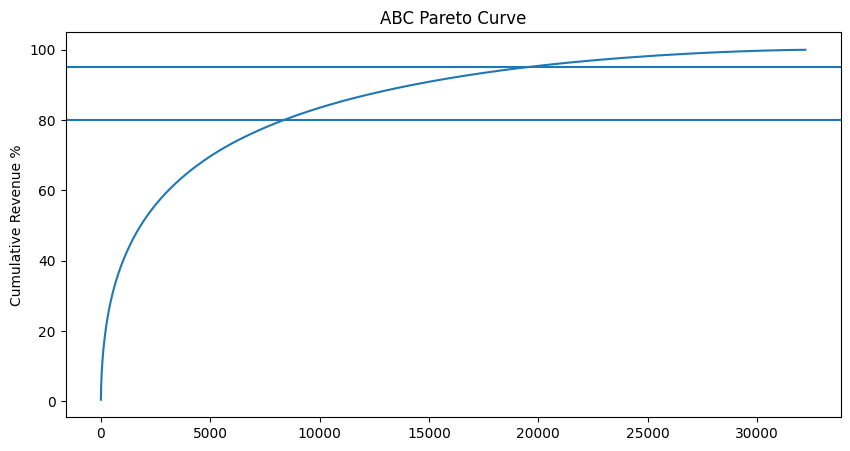

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(abc["cum_rev_pct"].values)
plt.axhline(80)
plt.axhline(95)

plt.title("ABC Pareto Curve")
plt.ylabel("Cumulative Revenue %")
plt.show()


EOQ vs Current Quantity

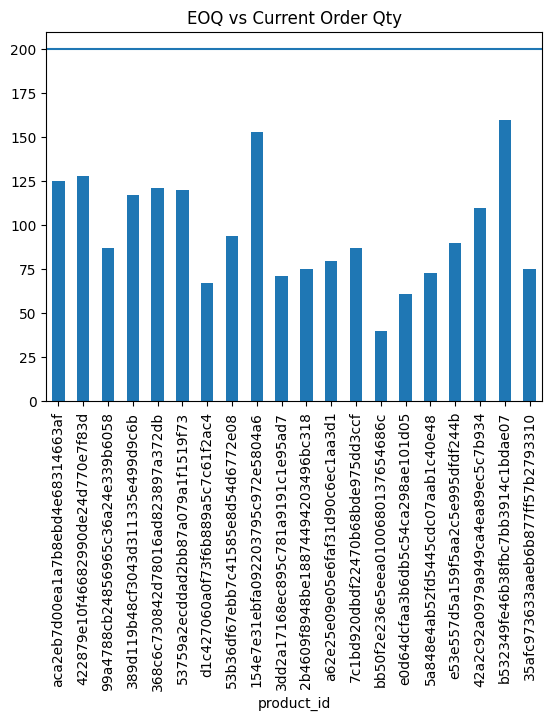

In [ ]:
top_products["EOQ"].plot(kind="bar")
plt.axhline(200)
plt.title("EOQ vs Current Order Qty")
plt.show()

Savings per Product

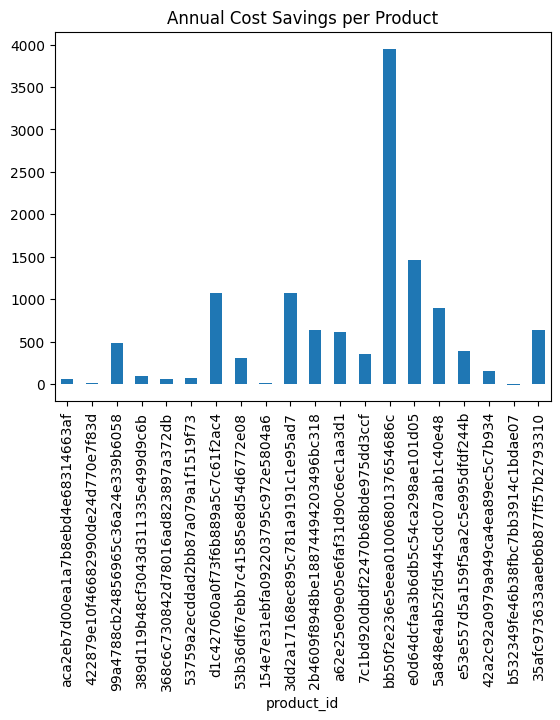

In [ ]:
top_products["savings"].plot(kind="bar")
plt.title("Annual Cost Savings per Product")
plt.show()

ROI CALCULATION

ROI

In [ ]:
investment = (
    top_products["safety_stock"] *
    top_products["unit_cost"]
).sum()

annual_savings = top_products["savings"].sum()

ROI = annual_savings / investment * 100

print("Safety Stock Investment:", investment)
print("Annual Savings:", annual_savings)
print("ROI %:", ROI)

Safety Stock Investment: 11749.219140873358
Annual Savings: 12330.73593180231
ROI %: 104.94940799006771


Save Results

In [ ]:
top_products.to_csv(DATA_PATH + "inventory_policy_results.csv")
abc.to_csv(DATA_PATH + "abc_results.csv")

print("Saved outputs ✅")

Saved outputs ✅
